# Focused validation of extracted drug–disease pairs

This notebook evaluates the manually reviewed sample in direct response to the reviewer concern that multiple extracted drug and disease mentions may generate incorrect drug–disease pairs.

Only rows from **eligible studies** are evaluated. In the annotation file, explicitly ineligible studies are marked `study_correct = 0`; eligible studies are otherwise left blank.

The analysis focuses on four questions:

1. How many candidate drug–disease pairs are generated per article?
2. What proportion of candidate pairs are manually valid?
3. Does pair-level accuracy change when each article is weighted equally, rather than allowing articles with many generated pairs to dominate?
4. What are the main reasons for invalid pairs?


In [33]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


DATA_PATH = Path("outputs/sampled_50_validation_drug_disease.csv")
df = pd.read_csv(DATA_PATH)

# Explicitly exclude ineligible studies.
eligible = df[df["study_correct"].fillna(1) != 0].copy()

# Pair-level evaluation uses rows with a manual pair-validity label.
pair_eval = eligible.dropna(subset=["drug_disease_pair_valid"]).copy()

print(f"Sampled articles overall: {df['PMID'].nunique()}")
print(f"Eligible articles: {eligible['PMID'].nunique()}")
print(f"Eligible candidate-pair rows: {len(eligible)}")
print(f"Pair-validity annotations available: {len(pair_eval)}")


Sampled articles overall: 50
Eligible articles: 38
Eligible candidate-pair rows: 195
Pair-validity annotations available: 195


## 1. Candidate pairs per article

Because one article can generate many drug–disease combinations, pair rows are not independent and articles contribute different numbers of rows. This is important when interpreting an overall pair-level proportion.


,Statistic,Value
0,Articles,38.00
1,Total candidate pairs,195.00
2,Mean,5.13
3,SD,3.92
4,Median,3.50
5,Q1,3.00
6,Q3,6.00
7,Minimum,2.00
8,Maximum,18.00


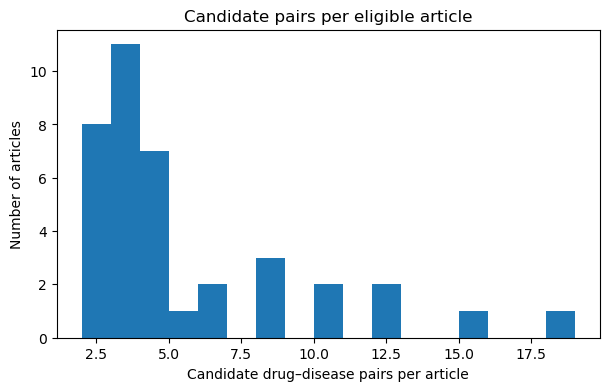

In [36]:
pairs_per_article = eligible.groupby("PMID").size()

pair_stats = pd.DataFrame({
    "Statistic": ["Articles", "Total candidate pairs", "Mean", "SD", "Median", "Q1", "Q3", "Minimum", "Maximum"],
    "Value": [
        len(pairs_per_article),
        pairs_per_article.sum(),
        pairs_per_article.mean(),
        pairs_per_article.std(),
        pairs_per_article.median(),
        pairs_per_article.quantile(0.25),
        pairs_per_article.quantile(0.75),
        pairs_per_article.min(),
        pairs_per_article.max(),
    ]
})

display(pair_stats.round(2))

plt.figure(figsize=(7, 4))
plt.hist(
    pairs_per_article,
    bins=range(int(pairs_per_article.min()), int(pairs_per_article.max()) + 2)
)
plt.xlabel("Candidate drug–disease pairs per article")
plt.ylabel("Number of articles")
plt.title("Candidate pairs per eligible article")
plt.show()


## 2. Overall validity of candidate pairs

The **pair-weighted estimate** answers:

> If one candidate pair is selected at random from the extracted resource, what is the probability that it is manually valid?

Every pair row contributes equally.


In [39]:
n_valid = int((pair_eval["drug_disease_pair_valid"] == 1).sum())
n_total = len(pair_eval)
micro_accuracy = n_valid / n_total

pd.DataFrame([{
    "Valid pairs": n_valid,
    "Evaluated pairs": n_total,
    "Pair-weighted validity (%)": 100 * micro_accuracy
}]).round(1)


,Valid pairs,Evaluated pairs,Pair-weighted validity (%)
0,148,195,75.9


## 3. Account for unequal numbers of pairs per article

A single problematic disease or drug mention can generate several invalid pair rows when combined with multiple mentions from the same article. Therefore, an article with many candidate pairs can have much more influence on the pair-weighted estimate than an article with only two pairs.

To examine this dependence, calculate pair validity within each article and then average across articles. This **article-weighted estimate** gives every article equal weight.

The pair-weighted and article-weighted estimates answer different questions, so both are reported.


In [42]:
article_results = (
    pair_eval.groupby("PMID")["drug_disease_pair_valid"]
    .agg(
        candidate_pairs="size",
        valid_pairs="sum",
        pair_validity="mean"
    )
    .reset_index()
)

macro_accuracy = article_results["pair_validity"].mean()

comparison = pd.DataFrame([
    {
        "Estimate": "Pair-weighted",
        "Validity (%)": 100 * micro_accuracy,
        "Interpretation": "Every candidate pair contributes equally"
    },
    {
        "Estimate": "Article-weighted",
        "Validity (%)": 100 * macro_accuracy,
        "Interpretation": "Every article contributes equally"
    }
])

display(comparison.round(1))


,Estimate,Validity (%),Interpretation
0,Pair-weighted,75.9,Every candidate pair contributes equally
1,Article-weighted,82.1,Every article contributes equally


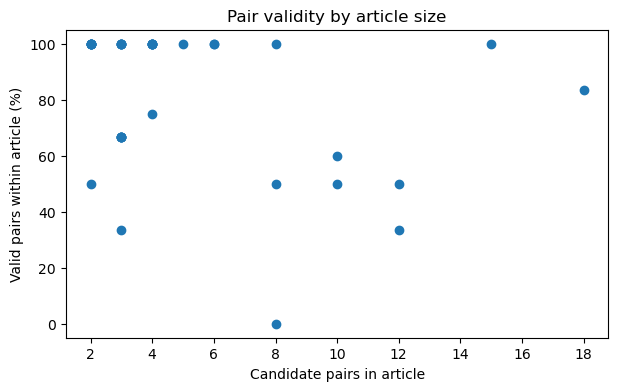

In [44]:
plt.figure(figsize=(7, 4))
plt.scatter(article_results["candidate_pairs"], 100 * article_results["pair_validity"])
plt.xlabel("Candidate pairs in article")
plt.ylabel("Valid pairs within article (%)")
plt.title("Pair validity by article size")
plt.ylim(-5, 105)
plt.show()


### Cluster-bootstrap uncertainty

For uncertainty intervals, articles—not individual pair rows—are resampled. All pair rows from a selected article stay together, preserving the within-article dependence.


In [47]:
def cluster_bootstrap(pair_df, n_boot=10000, seed=42):
    rng = np.random.default_rng(seed)
    pmids = pair_df["PMID"].unique()
    groups = {
        pmid: pair_df.loc[pair_df["PMID"] == pmid, "drug_disease_pair_valid"].to_numpy()
        for pmid in pmids
    }

    micro = np.empty(n_boot)
    macro = np.empty(n_boot)

    for b in range(n_boot):
        sampled_pmids = rng.choice(pmids, size=len(pmids), replace=True)
        sampled_arrays = [groups[p] for p in sampled_pmids]

        micro[b] = np.concatenate(sampled_arrays).mean()
        macro[b] = np.mean([x.mean() for x in sampled_arrays])

    return (
        np.quantile(micro, [0.025, 0.975]),
        np.quantile(macro, [0.025, 0.975])
    )

micro_ci, macro_ci = cluster_bootstrap(pair_eval)

pd.DataFrame([
    {
        "Estimate": "Pair-weighted",
        "Validity (%)": 100 * micro_accuracy,
        "Cluster-bootstrap 95% CI": f"{100*micro_ci[0]:.1f}–{100*micro_ci[1]:.1f}%"
    },
    {
        "Estimate": "Article-weighted",
        "Validity (%)": 100 * macro_accuracy,
        "Cluster-bootstrap 95% CI": f"{100*macro_ci[0]:.1f}–{100*macro_ci[1]:.1f}%"
    }
]).round(1)


,Estimate,Validity (%),Cluster-bootstrap 95% CI
0,Pair-weighted,75.9,64.7–86.7%
1,Article-weighted,82.1,73.3–89.7%


## 4. Reasons for invalid pairs

The manual `validation_notes_pair_validity` labels are summarized in two ways:

- **pair-level count:** how many invalid pair rows carry each error type;
- **article-level count:** how many distinct articles contain at least one error of that type.

The article-level count is important because one underlying error can propagate into several invalid pair rows.


In [49]:
invalid = pair_eval[
    pair_eval["drug_disease_pair_valid"] == 0
].copy()

invalid["reason"] = (
    invalid["validation_notes_pair_validity"]
    .fillna("not_categorized")
)

# --------------------------------------------------
# 1. Invalid pair rows per reason
# --------------------------------------------------
pair_reason = (
    invalid["reason"]
    .value_counts()
    .rename_axis("reason")
    .to_frame("invalid_pair_rows")
)

# --------------------------------------------------
# 2. Number of affected articles per reason
# --------------------------------------------------
article_reason = (
    invalid[["PMID", "reason"]]
    .drop_duplicates()
    .groupby("reason")
    .size()
    .rename("articles")
)

# --------------------------------------------------
# 3. Count unique underlying errors
# --------------------------------------------------

def underlying_error_key(row):
    reason = row["reason"]

    # Disease-side errors:
    # same disease error repeated across several drug pairs
    if reason in [
        "wrong_disease_entity_linking",
        "wrong_disease_extraction_NER",
        "background_disease_only",
    ]:
        return (
            row["PMID"],
            reason,
            row["unique_conditions_linkbert_predictions"],
            row["merged_mondo_label"],
        )

    # Drug-side errors:
    # same drug error repeated across several disease pairs
    elif reason in [
        "wrong_drug_entity_linking",
        "wrong_drug_extraction_NER",
        "wrong_drug_entity_type",
        "wrong_drug_extraction",
    ]:
        return (
            row["PMID"],
            reason,
            row["unique_interventions_linkbert_predictions"],
            row["merged_umls_label"],
        )

    # Both sides wrong:
    # retain both disease and drug identity
    elif reason == "wrong_both_extraction_NER":
        return (
            row["PMID"],
            reason,
            row["unique_conditions_linkbert_predictions"],
            row["merged_mondo_label"],
            row["unique_interventions_linkbert_predictions"],
            row["merged_umls_label"],
        )

    # Fallback: treat the row as its own error instance
    else:
        return (
            row["PMID"],
            reason,
            row["unique_conditions_linkbert_predictions"],
            row["merged_mondo_label"],
            row["unique_interventions_linkbert_predictions"],
            row["merged_umls_label"],
        )


invalid["underlying_error"] = invalid.apply(
    underlying_error_key,
    axis=1
)

unique_error_reason = (
    invalid[
        ["reason", "underlying_error"]
    ]
    .drop_duplicates()
    .groupby("reason")
    .size()
    .rename("unique_underlying_errors")
)

# --------------------------------------------------
# 4. Combine everything
# --------------------------------------------------
reason_summary = (
    pair_reason
    .join(unique_error_reason)
    .join(article_reason)
)

reason_summary["% of invalid pair rows"] = (
    100
    * reason_summary["invalid_pair_rows"]
    / len(invalid)
)

# Optional: show how much each underlying error was amplified
reason_summary["pairs_per_underlying_error"] = (
    reason_summary["invalid_pair_rows"]
    / reason_summary["unique_underlying_errors"]
)

display(
    reason_summary[
        [
            "invalid_pair_rows",
            "unique_underlying_errors",
            "articles",
            "pairs_per_underlying_error",
            "% of invalid pair rows",
        ]
    ].round(2)
)

,invalid_pair_rows,unique_underlying_errors,articles,pairs_per_underlying_error,% of invalid pair rows
reason,,,,,
wrong_disease_entity_linking,11,4,4,2.75,23.40
wrong_disease_extraction_NER,9,4,4,2.25,19.15
wrong_drug_entity_type,8,2,1,4.00,17.02
wrong_drug_extraction_NER,7,4,4,1.75,14.89
wrong_drug_entity_linking,6,4,3,1.50,12.77
background_disease_only,5,3,2,1.67,10.64
wrong_both_extraction_NER,1,1,1,1.00,2.13


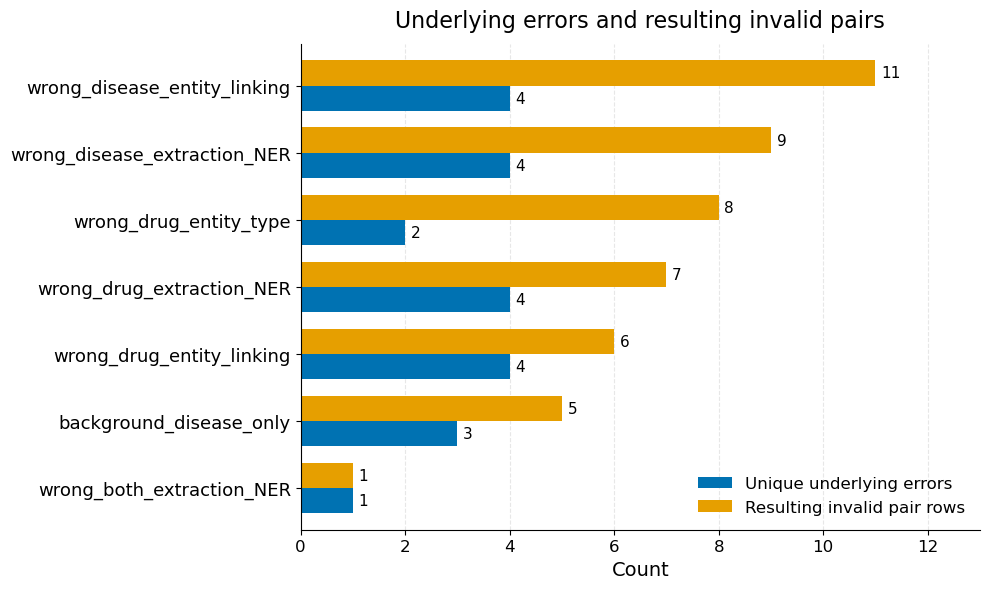

In [64]:
plot_reason = reason_summary.sort_values("invalid_pair_rows")

# Okabe–Ito palette
colors = ["#0072B2", "#E69F00"]

ax = plot_reason[
    ["unique_underlying_errors", "invalid_pair_rows"]
].plot(
    kind="barh",
    figsize=(10, 6),
    color=colors,
    width=0.75
)

ax.set_xlabel("Count", fontsize=14)
ax.set_ylabel("")
ax.set_title(
    "Underlying errors and resulting invalid pairs",
    fontsize=16,
    pad=12
)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=13)

ax.legend(
    ["Unique underlying errors", "Resulting invalid pair rows"],
    frameon=False,
    fontsize=12
)

ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add values at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=4,
        fontsize=11
    )

# Give labels a little extra space
ax.set_xlim(
    0,
    plot_reason["invalid_pair_rows"].max() + 2
)

plt.tight_layout()

plt.savefig(
    "viz/drug_disease_error_propagation.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "viz/drug_disease_error_propagation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Compact reviewer-facing summary

The two validity estimates should be reported together:

- **Pair-weighted validity** describes the quality of individual candidate pair rows in the resource.
- **Article-weighted validity** addresses the fact that one erroneous mention can generate several invalid pairs and gives each source article equal influence.

The error-reason table then explains which upstream failures account for invalid pairs, rather than treating all invalid combinations as independent pair-construction errors.


In [55]:
summary = pd.DataFrame([
    {"Measure": "Eligible articles", "Result": f"{eligible['PMID'].nunique()}"},
    {"Measure": "Evaluated candidate pairs", "Result": f"{n_total}"},
    {
        "Measure": "Pairs/article",
        "Result": (
            f"mean {pairs_per_article.mean():.1f}, "
            f"median {pairs_per_article.median():.1f}, "
            f"range {pairs_per_article.min()}–{pairs_per_article.max()}"
        )
    },
    {
        "Measure": "Pair-weighted validity",
        "Result": f"{n_valid}/{n_total} = {100*micro_accuracy:.1f}% "
                  f"(cluster-bootstrap 95% CI {100*micro_ci[0]:.1f}–{100*micro_ci[1]:.1f}%)"
    },
    {
        "Measure": "Article-weighted validity",
        "Result": f"{100*macro_accuracy:.1f}% "
                  f"(cluster-bootstrap 95% CI {100*macro_ci[0]:.1f}–{100*macro_ci[1]:.1f}%)"
    }
])

display(summary)


,Measure,Result
0,Eligible articles,38
1,Evaluated candidate pairs,195
2,Pairs/article,"mean 5.1, median 3.5, range 2–18"
3,Pair-weighted validity,148/195 = 75.9% (cluster-bootstrap 95% CI 64.7–86.7%)
4,Article-weighted validity,82.1% (cluster-bootstrap 95% CI 73.3–89.7%)


## Interpretation for the rebuttal

A concise response to the reviewer can emphasize:

1. **End-to-end manual validation:** the manually reviewed pair labels assess the final extracted resource after study selection, extraction, linking, and pair generation, rather than relying only on component-level NLP F1 scores.
2. **Difficult sampling frame:** the validation specifically targets articles with multiple candidate drug–disease pairs, where false combinations are most likely.
3. **Dependence is acknowledged:** because one erroneous entity can generate several invalid pair rows, both pair-weighted and article-weighted validity are reported, with article-level cluster-bootstrap confidence intervals.
4. **Failure modes are characterized:** invalid pairs are broken down by manual error reason, allowing the reviewer to see whether errors arise from NER, entity linking, background-only concepts, wrong semantic entity type, or other causes.
5. **Traceability:** if the released resource retains PMID, extracted surface form, and normalized concept identifiers, mention this explicitly so users can inspect individual NLP-derived records rather than treating the resource as unqualified ground truth.
